# Глава 4.

### Пономарев Т. Е. 5130901/30201

## Упражнение 4.1

«A Soft Murmur» — это веб-сайт, на котором можно прослушать подборку звуков природы, включая шум дождя, волн, ветра и т. д. По адресу http://asoftmurmur.com/about/ вы найдете список записей, большинство из которых доступно по ссылке http://freesound.org.
Скачайте несколько из этих файлов и вычислите спектр каждого сигнала. Похож ли спектр мощности на белый шум, розовый шум или броуновский шум? Как спектр изменяется во времени?

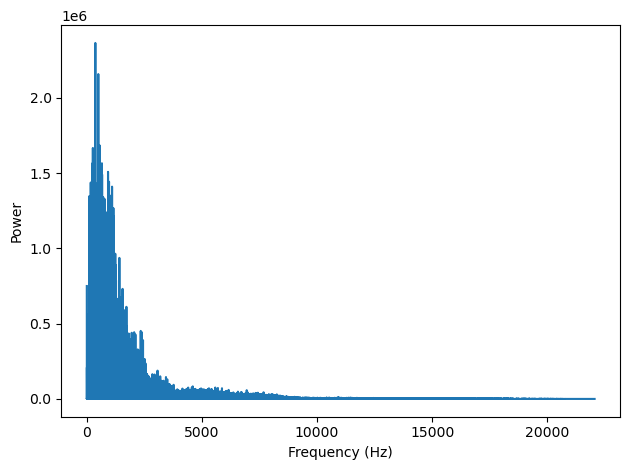

In [5]:
from thinkdsp import read_wave, decorate

wave = read_wave('404686__norwayjohn__ocean-crete-2.wav')
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power')
wave.make_audio()

Что-то около красного или розового шумов

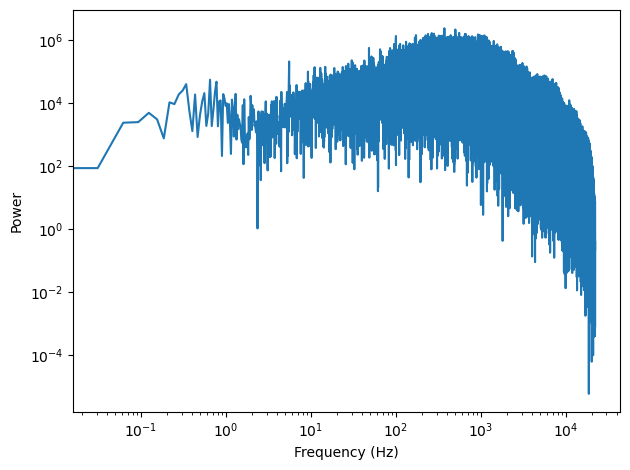

In [6]:
spectrum.plot_power()

loglog = dict(xscale="log", yscale="log")
decorate(xlabel="Frequency (Hz)", ylabel="Power", **loglog)

## Упражнение 4.2
В шумовом сигнале соотношение частот меняется во времени. В долгосрочной перспективе можно ожидать, что мощность на всех частотах будет одинаковой, однако в любой отдельной выборке мощность на каждой частоте является случайной.

Чтобы оценить долгосрочную среднюю мощность на каждой частоте, мы можем разбить длинный сигнал на сегменты, вычислить спектр мощности для каждого сегмента, а затем вычислить среднее значение по всем сегментам. Подробнее об этом алгоритме можно прочитать по адресу http://en.wikipedia.org/wiki/Bartlett's_method.

Реализуйте метод Бартлетта и используйте его для оценки спектра мощности для шумовой волны. Подсказка: посмотрите на реализацию функции make_spectrogram.

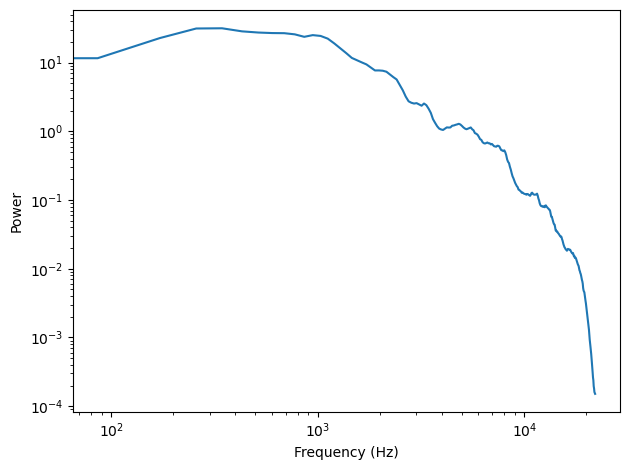

In [13]:
from thinkdsp import Spectrum
import numpy as np

def bartlett_method(wave, seg_length = 512, win_flag = True):
    spectrogram = wave.make_spectrogram(seg_length, win_flag)
    spectrums = spectrogram.spec_map.values()
    psds = [spectrum.power for spectrum in spectrums]
    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(spectrums)).fs
    spectrum = Spectrum(hs, fs, wave.framerate)
    return spectrum

bartlett = bartlett_method(wave)
bartlett.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

## Упражнение 4.3
На сайте [coindesk](https://www.coindesk.com/price/bitcoin) можно скачать данные о дневных ценах на биткойн в виде файла CSV.  Проанализируйте этот файл и вычислите
спектр цен на биткойн в зависимости от времени.
На что он похож: на белый, розовый или броуновский шум?

In [14]:
import pandas as pd

df = pd.read_csv('btc-usd-max.csv', parse_dates=[0])
df

,snapped_at,price,market_cap,total_volume
0,2013-04-28 00:00:00+00:00,135.300000,1.500518e+09,0.000000e+00
1,2013-04-29 00:00:00+00:00,141.960000,1.575032e+09,0.000000e+00
2,2013-04-30 00:00:00+00:00,135.300000,1.501657e+09,0.000000e+00
3,2013-05-01 00:00:00+00:00,117.000000,1.298952e+09,0.000000e+00
4,2013-05-02 00:00:00+00:00,103.430000,1.148668e+09,0.000000e+00
...,...,...,...,...
4769,2026-05-21 00:00:00+00:00,77459.944346,1.551690e+12,2.863719e+10
4770,2026-05-22 00:00:00+00:00,77546.337653,1.554828e+12,2.907525e+10
4771,2026-05-23 00:00:00+00:00,75482.523800,1.512165e+12,3.031402e+10
4772,2026-05-24 00:00:00+00:00,76672.792891,1.536316e+12,3.302147e+10


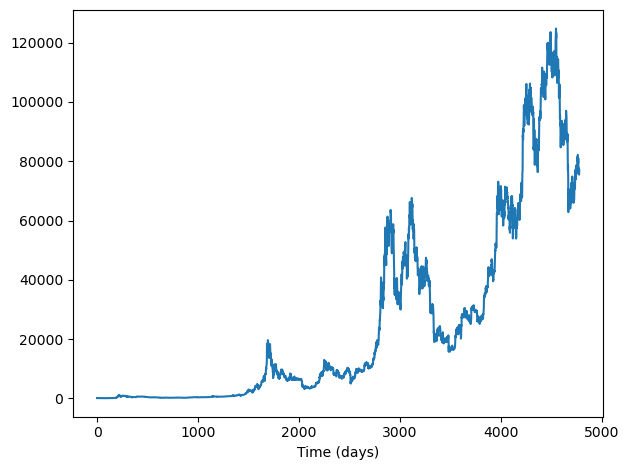

In [17]:
from thinkdsp import Wave

ys = df['price']
ts = df.index

wave = Wave(ys, ts, framerate=1)
wave.plot()
decorate(xlabel='Time (days)')

np.float64(-1.7616598076118626)

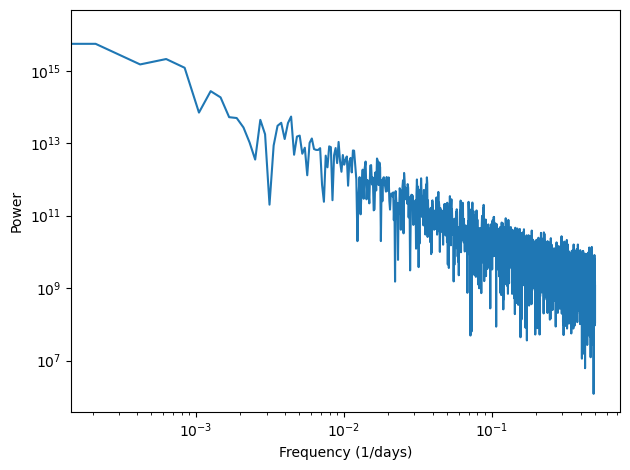

In [18]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (1/days)', ylabel='Power', **loglog)
spectrum.estimate_slope()[0]

Красный шум должен иметь наклон -2. Наклон этой спектральной плотности мощности около 1,7. Трудно сказать, следует ли считать его красным или розовым шумом.

## Упражнение 4.4
Счетчик Гейгера — это устройство, предназначенное для обнаружения излучения. Когда ионизирующая частица попадает на детектор, он генерирует импульс тока. Общий выходной сигнал в данный момент времени можно смоделировать как некоррелированный шум Пуассона (UP), где каждая выборка представляет собой случайную величину из распределения Пуассона, соответствующую количеству частиц, обнаруженных за интервал времени.

Напишите класс UncorrelatedPoissonNoise, который наследуется от thinkdsp_Noise и предоставляет метод evaluate. Он должен использовать np.random.poisson для генерации случайных значений из распределения Пуассона. Параметр этой функции, lam, представляет собой среднее количество частиц за каждый интервал. Для задания lam можно использовать атрибут amp. Например, если частота кадров составляет 10 кГц, а amp равен 0,001, мы ожидаем около 10 «щелчков» в секунду.

Сгенерируйте примерно секунду шума UP и прослушайте его. При низких значениях amp, таких как 0,001, он должен звучать как счетчик Гейгера. При более высоких значениях он должен звучать как белый шум. Вычислите и постройте спектр мощности, чтобы увидеть, похож ли он на белый шум.

In [19]:
from thinkdsp import Noise

class UncorrelatedPoissonNoise(Noise):
    def evaluate(self, ts):
        ys = np.random.poisson(self.amp, len(ts))
        return ys

amp = 0.001
framerate = 10000
duration = 1

signal = UncorrelatedPoissonNoise(amp=amp)
wave = signal.make_wave(duration=duration, framerate=framerate)
wave.make_audio()

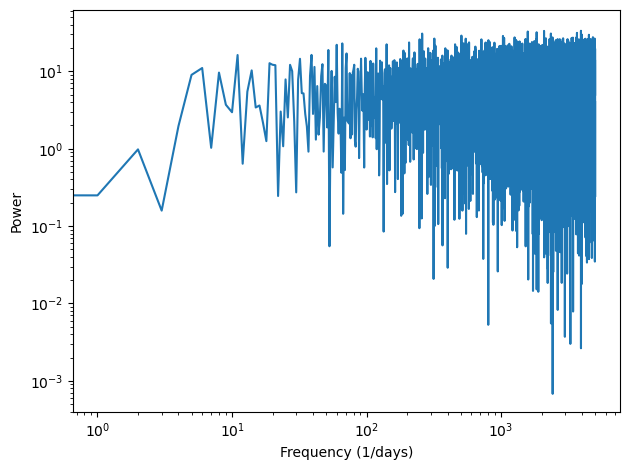

In [21]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (1/days)', ylabel='Power', **loglog)

Похоже на белый шум

## Упражнение 4.5
Алгоритм генерации розового шума, описанный в этой главе, прост в теоретическом плане, но требует значительных вычислительных ресурсов. Существуют более эффективные альтернативы, такие как алгоритм Восса-Маккартни. Изучите этот метод, реализуйте его, рассчитайте спектр полученного результата и убедитесь, что он имеет требуемое соотношение между мощностью и частотой.

C:\Users\ponom\AppData\Local\Temp\ipykernel_14008\2747724340.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", axis=0, inplace=True)


array([7.18247711, 7.45105129, 7.1105055 , ..., 7.7915238 , 8.33142878,
       8.26297297], shape=(5000,))

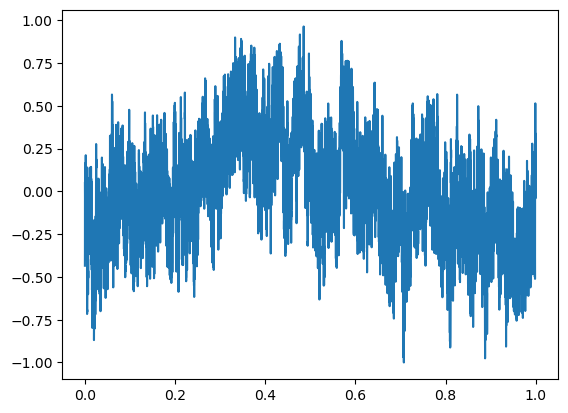

In [27]:
def voss(nrows, ncols=16):
    array = np.empty((nrows, ncols))
    array.fill(np.nan)
    array[0, :] = np.random.random(ncols)
    array[:, 0] = np.random.random(nrows)

    n = nrows
    cols = np.random.geometric(0.5, n)
    cols[cols >= ncols] = 0
    rows = np.random.randint(nrows, size=n)
    array[rows, cols] = np.random.random(n)

    df = pd.DataFrame(array)
    df.fillna(method="ffill", axis=0, inplace=True)
    total = df.sum(axis=1)

    return total.values

wave = Wave(ys)
wave.unbias()
wave.normalize()
wave.plot()

ys = voss(5000)
ys

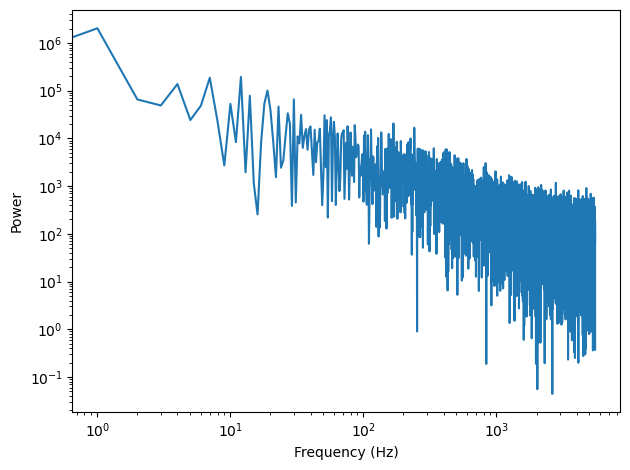

In [28]:
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
spectrum.plot_power()
decorate(xlabel="Frequency (Hz)", ylabel="Power", **loglog)


wave.make_audio()